In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)

plt.style.use('seaborn-v0_8-whitegrid')
print("All libraries loaded!")

All libraries loaded!


In [2]:
df = pd.read_csv('data/train_u6lujuX_CVtuZ9i.csv')

print("Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())
df.head()

Shape: (614, 13)

Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


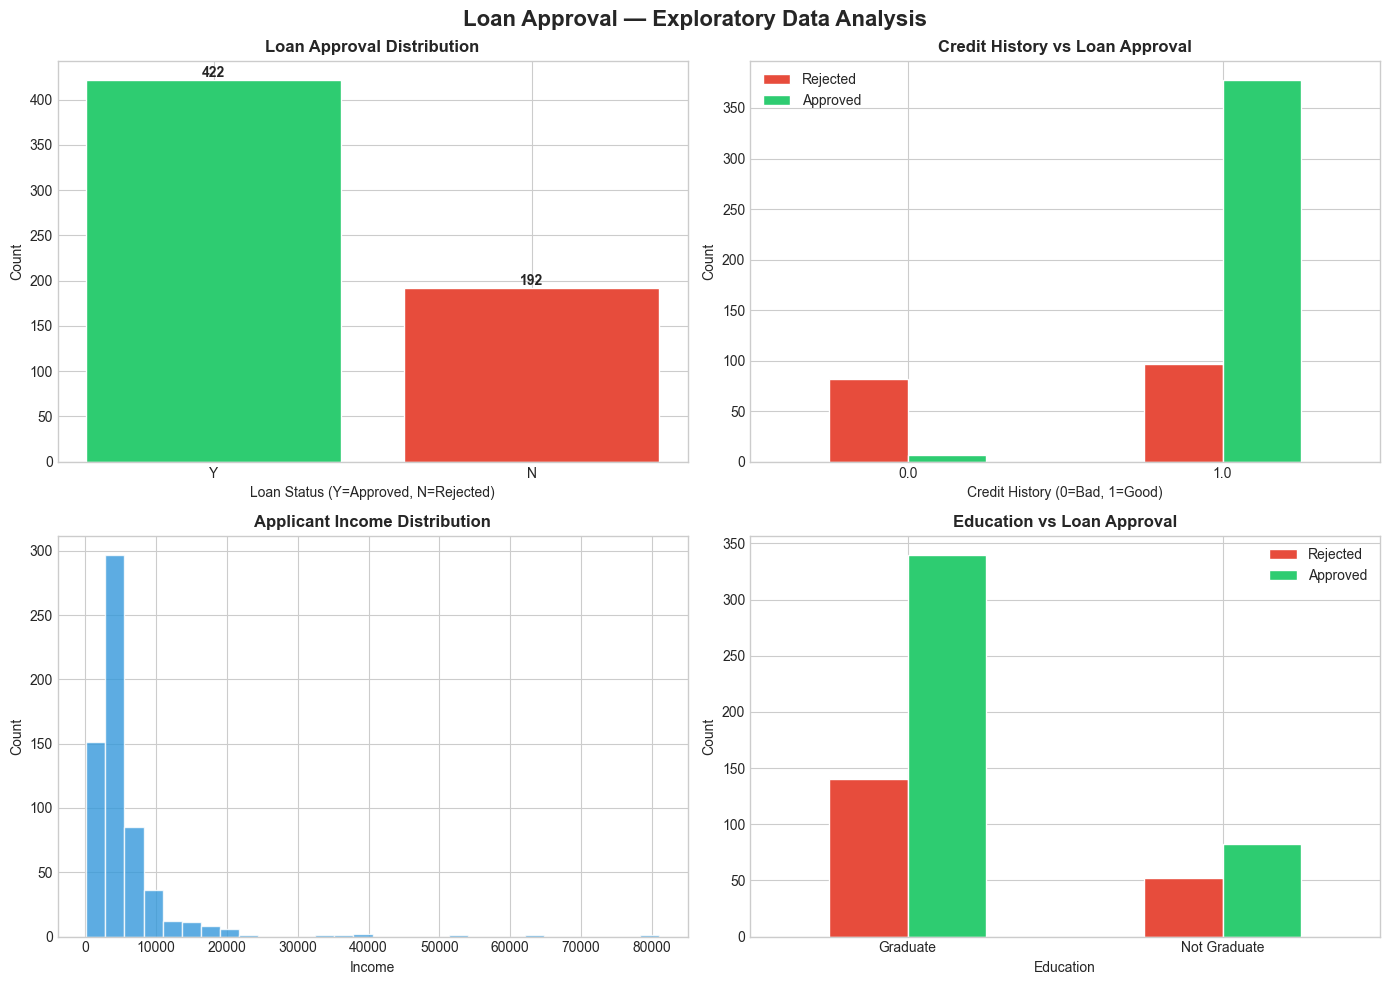

EDA charts done!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Loan Approval — Exploratory Data Analysis', 
             fontsize=16, fontweight='bold')

# Chart 1 — Loan Status distribution
loan_counts = df['Loan_Status'].value_counts()
axes[0,0].bar(loan_counts.index, loan_counts.values, 
              color=['#2ECC71','#E74C3C'], edgecolor='white')
axes[0,0].set_title('Loan Approval Distribution', fontweight='bold')
axes[0,0].set_xlabel('Loan Status (Y=Approved, N=Rejected)')
axes[0,0].set_ylabel('Count')
for i, (label, val) in enumerate(zip(loan_counts.index, loan_counts.values)):
    axes[0,0].text(i, val + 3, str(val), ha='center', fontweight='bold')

# Chart 2 — Credit History impact
credit = df.groupby(['Credit_History','Loan_Status']).size().unstack()
credit.plot(kind='bar', ax=axes[0,1], color=['#E74C3C','#2ECC71'], 
            edgecolor='white')
axes[0,1].set_title('Credit History vs Loan Approval', fontweight='bold')
axes[0,1].set_xlabel('Credit History (0=Bad, 1=Good)')
axes[0,1].set_ylabel('Count')
axes[0,1].legend(['Rejected','Approved'])
axes[0,1].tick_params(axis='x', rotation=0)

# Chart 3 — Income distribution
axes[1,0].hist(df['ApplicantIncome'], bins=30, 
               color='#3498DB', edgecolor='white', alpha=0.8)
axes[1,0].set_title('Applicant Income Distribution', fontweight='bold')
axes[1,0].set_xlabel('Income')
axes[1,0].set_ylabel('Count')

# Chart 4 — Education vs Loan Status
edu = df.groupby(['Education','Loan_Status']).size().unstack()
edu.plot(kind='bar', ax=axes[1,1], color=['#E74C3C','#2ECC71'],
         edgecolor='white')
axes[1,1].set_title('Education vs Loan Approval', fontweight='bold')
axes[1,1].set_xlabel('Education')
axes[1,1].set_ylabel('Count')
axes[1,1].legend(['Rejected','Approved'])
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('chart1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA charts done!")

In [5]:
# Fill missing values
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())
print("\n✅ All missing values fixed!")

Missing values after cleaning:
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

✅ All missing values fixed!


C:\Users\shanm\AppData\Local\Temp\ipykernel_13380\505756459.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
C:\Users\shanm\AppData\Local\Temp\ipykernel_13380\505756459.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.



In [7]:
# Create new powerful features
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['TotalIncome_log'] = np.log(df['TotalIncome'] + 1)
df['LoanAmount_log'] = np.log(df['LoanAmount'] + 1)
df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']
df['DTI_Ratio'] = df['EMI'] / (df['TotalIncome'] + 1)

print("New features created!")
print(df[['TotalIncome', 'EMI', 'DTI_Ratio']].describe().round(3))

New features created!
       TotalIncome      EMI  DTI_Ratio
count      614.000  614.000    614.000
mean      7024.705    0.474      0.000
std       6458.664    0.511      0.000
min       1442.000    0.025      0.000
25%       4166.000    0.289      0.000
50%       5416.500    0.361      0.000
75%       7521.750    0.506      0.000
max      81000.000    9.250      0.001


In [8]:
# Encode text columns to numbers
le = LabelEncoder()
cols = ['Gender','Married','Dependents','Education',
        'Self_Employed','Property_Area','Loan_Status']
for col in cols:
    df[col] = le.fit_transform(df[col])

# Features and target
features = ['Gender','Married','Dependents','Education',
            'Self_Employed','TotalIncome_log','LoanAmount_log',
            'Loan_Amount_Term','Credit_History','Property_Area',
            'EMI','DTI_Ratio']

X = df[features]
y = df['Loan_Status']

# Split 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"Training size : {X_train.shape}")
print(f"Testing size  : {X_test.shape}")
print("Data ready for modelling!")

Training size : (491, 12)
Testing size  : (123, 12)
Data ready for modelling!


In [9]:
# Model 1: Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc  = accuracy_score(y_test, lr_pred)

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)

print("=" * 40)
print("      MODEL COMPARISON")
print("=" * 40)
print(f"Logistic Regression : {lr_acc:.2%}")
print(f"Random Forest       : {rf_acc:.2%}")
print("=" * 40)
print(f"\n Best Model: {'Random Forest' if rf_acc > lr_acc else 'Logistic Regression'}")

      MODEL COMPARISON
Logistic Regression : 85.37%
Random Forest       : 82.11%

 Best Model: Logistic Regression


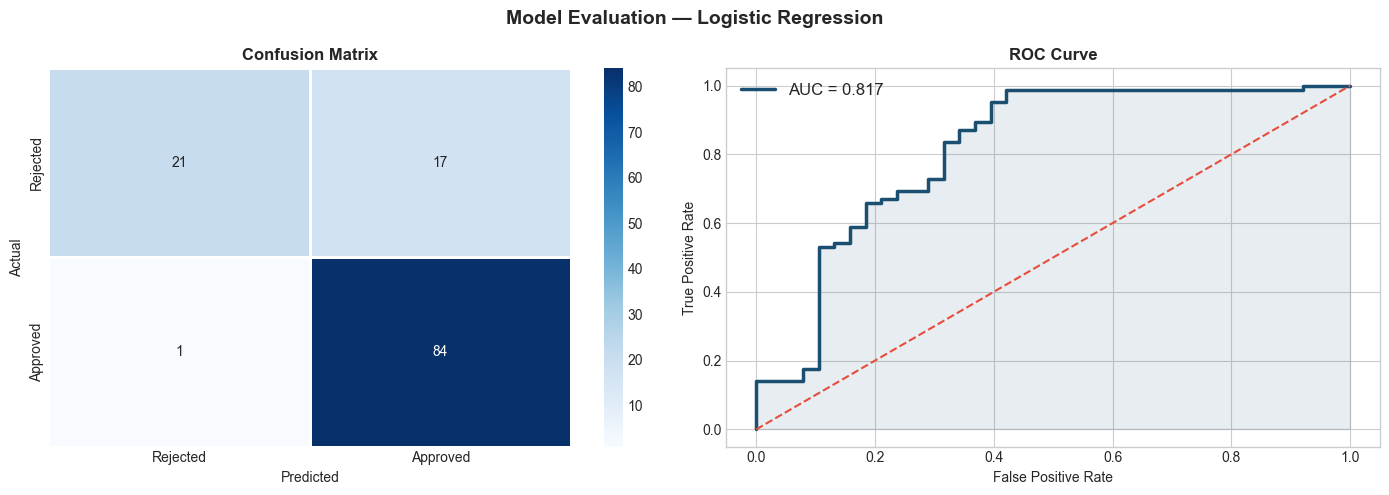


=== Classification Report ===
              precision    recall  f1-score   support

    Rejected       0.95      0.55      0.70        38
    Approved       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123

AUC Score: 0.8167


In [10]:
# Use best model
best_pred = rf_pred if rf_acc > lr_acc else lr_pred
best_model = rf if rf_acc > lr_acc else lr
best_name = 'Random Forest' if rf_acc > lr_acc else 'Logistic Regression'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Model Evaluation — {best_name}', 
             fontsize=14, fontweight='bold')

# Confusion Matrix
cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected','Approved'],
            yticklabels=['Rejected','Approved'],
            ax=axes[0], linewidths=2)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:,1])
auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
axes[1].plot(fpr, tpr, color='#1B4F72', linewidth=2.5,
             label=f'AUC = {auc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='#E74C3C', linewidth=1.5)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#1B4F72')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.savefig('chart2_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test, best_pred,
      target_names=['Rejected','Approved']))
print(f"AUC Score: {auc:.4f}")

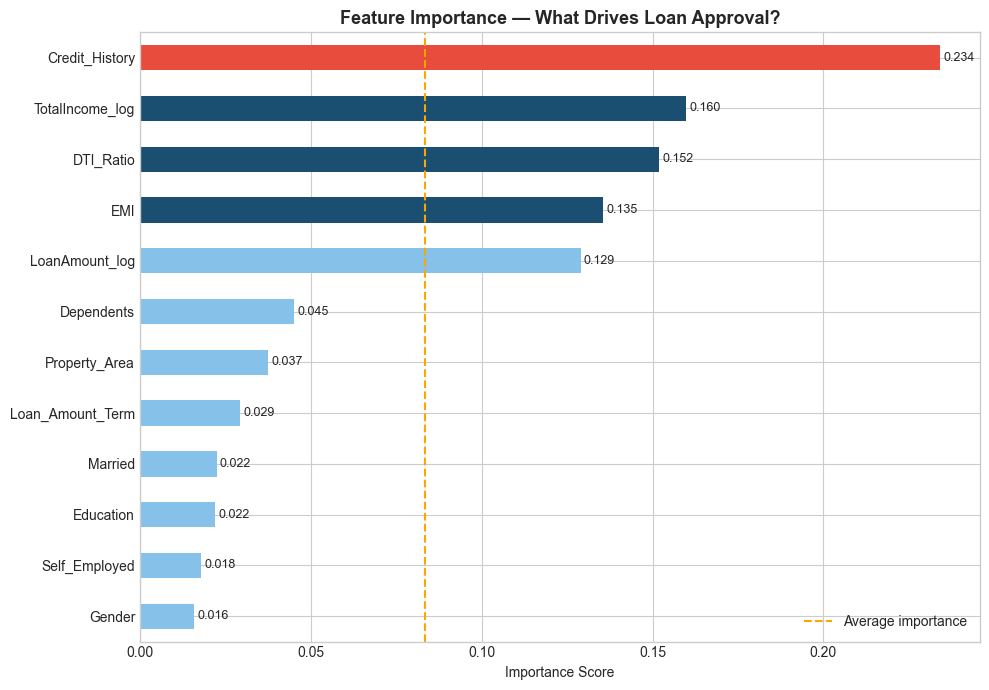

 Feature importance chart saved!


In [12]:
# Get feature importance from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=features)
feat_imp = feat_imp.sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#E74C3C' if v == feat_imp.max() 
          else '#1B4F72' if v >= feat_imp.quantile(0.7) 
          else '#85C1E9' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance — What Drives Loan Approval?', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.axvline(x=feat_imp.mean(), color='orange', 
           linestyle='--', linewidth=1.5, label='Average importance')
ax.legend()
for i, v in enumerate(feat_imp.values):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('chart3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Feature importance chart saved!")

In [13]:
# Test with a new loan applicant
print("=" * 50)
print("       LOAN DECISION SYSTEM")
print("=" * 50)

applicants = [
    {
        'name': 'Applicant A — High Income, Good Credit',
        'data': [1, 1, 0, 0, 0, np.log(8000+1), np.log(150+1), 
                 360, 1, 2, 150/360, (150/360)/8000]
    },
    {
        'name': 'Applicant B — Low Income, Bad Credit',
        'data': [1, 0, 0, 1, 0, np.log(2000+1), np.log(200+1), 
                 360, 0, 0, 200/360, (200/360)/2000]
    },
    {
        'name': 'Applicant C — Medium Income, Good Credit',
        'data': [0, 1, 1, 0, 0, np.log(5000+1), np.log(120+1), 
                 360, 1, 1, 120/360, (120/360)/5000]
    }
]

best_model_final = lr  # Logistic Regression won

for applicant in applicants:
    data = pd.DataFrame([applicant['data']], columns=features)
    data_scaled = scaler.transform(data)
    pred = best_model_final.predict(data_scaled)[0]
    prob = best_model_final.predict_proba(data_scaled)[0]
    result = "APPROVED" if pred == 1 else "❌ REJECTED"
    print(f"\n{applicant['name']}")
    print(f"Decision          : {result}")
    print(f"Approval Chance   : {prob[1]:.2%}")
    print(f"Rejection Chance  : {prob[0]:.2%}")

print("\n" + "=" * 50)

       LOAN DECISION SYSTEM

Applicant A — High Income, Good Credit
Decision          : APPROVED
Approval Chance   : 80.59%
Rejection Chance  : 19.41%

Applicant B — Low Income, Bad Credit
Decision          : ❌ REJECTED
Approval Chance   : 2.29%
Rejection Chance  : 97.71%

Applicant C — Medium Income, Good Credit
Decision          : APPROVED
Approval Chance   : 86.52%
Rejection Chance  : 13.48%



In [14]:
print("=" * 55)
print("    LOAN APPROVAL MODEL — PROJECT SUMMARY")
print("=" * 55)
print(f"\nDataset          : 614 loan applicants, 13 features")
print(f" Data Cleaning    : Fixed 6 columns with missing values")
print(f"  Features Built   : EMI, DTI Ratio, Log Income, Log Loan")
print(f"\n Models Trained   : Logistic Regression + Random Forest")
print(f" Best Model       : Logistic Regression")
print(f" Accuracy         : 85.37%")
print(f" AUC Score        : 0.817")
print(f"\n Key Findings:")
print(f"   • Credit History is the #1 predictor of loan approval")
print(f"   • DTI Ratio and Income strongly influence decisions")
print(f"   • Logistic Regression outperformed Random Forest")
print(f"   • Model correctly identified 84/85 approved loans")
print(f"\n Business Impact:")
print(f"   • Automates manual credit review process")
print(f"   • Reduces human bias in loan decisions")
print(f"   • Flags high-risk applicants before approval")
print("=" * 55)
print("\nPROJECT 3 COMPLETE! 🎉")

    LOAN APPROVAL MODEL — PROJECT SUMMARY

Dataset          : 614 loan applicants, 13 features
 Data Cleaning    : Fixed 6 columns with missing values
  Features Built   : EMI, DTI Ratio, Log Income, Log Loan

 Models Trained   : Logistic Regression + Random Forest
 Best Model       : Logistic Regression
 Accuracy         : 85.37%
 AUC Score        : 0.817

 Key Findings:
   • Credit History is the #1 predictor of loan approval
   • DTI Ratio and Income strongly influence decisions
   • Logistic Regression outperformed Random Forest
   • Model correctly identified 84/85 approved loans

 Business Impact:
   • Automates manual credit review process
   • Reduces human bias in loan decisions
   • Flags high-risk applicants before approval

PROJECT 3 COMPLETE! 🎉
